LẤY DỮ LIỆU

In [ ]:
import csv
import json
import re
import time
import shutil
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode, urlparse
from urllib.request import Request, urlopen

# ==== CHỈNH Ở ĐÂY ====
# chỉnh TAXON- 5 số theo loài
# chỉnh OUT theo tên loài
TAXON = "https://www.inaturalist.org/taxa/1119882-Enhydris-subtaeniata/browse_photos"
OUT = "/content/Trimerodytes_percarinatus_inaturalist"
SIZE = "large"
CC_ONLY = True
DELAY = 0.25
MAX_PHOTOS = 200
# =====================

API_URL = "https://api.inaturalist.org/v1/observations"
USER_AGENT = "inat-research-photo-downloader/1.0"
CC_LICENSES = "cc0,cc-by,cc-by-sa,cc-by-nc,cc-by-nc-sa,cc-by-nd,cc-by-nc-nd"


def parse_taxon(value):
    match = re.search(r"/taxa/(\d+)", value)
    if match:
        return "taxon_id", match.group(1)
    if str(value).isdigit():
        return "taxon_id", str(value)
    raise ValueError("Trong Colab nên dùng taxon URL hoặc taxon ID, ví dụ 99985")


def get_bytes(url, timeout=60, retries=4):
    last_error = None

    for attempt in range(retries + 1):
        try:
            req = Request(url, headers={"User-Agent": USER_AGENT})
            with urlopen(req, timeout=timeout) as res:
                return res.read()

        except HTTPError as e:
            last_error = e
            if e.code not in (429, 500, 502, 503, 504) or attempt == retries:
                raise

        except (URLError, TimeoutError, OSError) as e:
            last_error = e
            if attempt == retries:
                raise
        time.sleep(min(60, 2 ** attempt))
    raise last_error

def get_json(params):
    url = API_URL + "?" + urlencode(params)
    return json.loads(get_bytes(url, timeout=120).decode("utf-8"))

def replace_size(url, size):
    return re.sub(
        r"/(square|thumb|small|medium|large|original)(\.[A-Za-z0-9]+)(?=$|\?)",
        lambda m: f"/{size}{m.group(2)}",
        url,
    )

def candidate_urls(photo, preferred_size):
    base = photo.get("url") or photo.get("medium_url") or photo.get("square_url")
    if not base:
        return []
    sizes = [preferred_size, "large", "medium", "original", "square"]
    urls = []
    for size in sizes:
        url = replace_size(base, size)
        if url not in urls:
            urls.append(url)
    return urls

def file_ext(url):
    ext = Path(urlparse(url).path).suffix.lower()
    return ext if ext in [".jpg", ".jpeg", ".png", ".gif"] else ".jpg"

def download_inat_photos():
    key, value = parse_taxon(TAXON)
    out_dir = Path(OUT)
    img_dir = out_dir / "images"
    img_dir.mkdir(parents=True, exist_ok=True)
    meta_path = out_dir / "metadata.csv"
    fields = [
        "photo_id", "observation_id", "taxon_id", "taxon_name", "observed_on",
        "quality_grade", "user_login", "license_code", "attribution",
        "observation_url", "photo_url", "local_file", "downloaded", "error",
    ]
    page = 1
    per_page = min(200, MAX_PHOTOS)
    total_photos = 0
    downloaded = 0
    failed = 0
    with meta_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        while downloaded < MAX_PHOTOS:
            params = {
                key: value,
                "photos": "true",
                "per_page": per_page,
                "page": page,
                "order_by": "id",
                "order": "asc",
            }
            if CC_ONLY:
                params["photo_license"] = CC_LICENSES
            data = get_json(params)
            results = data.get("results", [])

            if not results:
                break
            for obs in results:
                photos = obs.get("observation_photos") or []
                for index, item in enumerate(photos, start=1):
                    if downloaded >= MAX_PHOTOS:
                        break
                    photo = item.get("photo") or {}
                    photo_id = photo.get("id")
                    total_photos += 1
                    ok = False
                    error = ""
                    used_url = ""
                    file_path = ""
                    for url in candidate_urls(photo, SIZE):
                        ext = file_ext(url)
                        file_name = f"obs{obs['id']}_photo{photo_id}_{index}{ext}"
                        file_path = img_dir / file_name
                        try:
                            if file_path.exists() and file_path.stat().st_size > 0:
                                ok = True
                            else:
                                file_path.write_bytes(get_bytes(url, timeout=90))
                                time.sleep(DELAY)
                            used_url = url
                            ok = True
                            break
                        except Exception as e:
                            error = str(e)
                    if ok:
                        downloaded += 1
                    else:
                        failed += 1

                    writer.writerow({
                        "photo_id": photo_id,
                        "observation_id": obs.get("id"),
                        "taxon_id": (obs.get("taxon") or {}).get("id"),
                        "taxon_name": (obs.get("taxon") or {}).get("name"),
                        "observed_on": obs.get("observed_on"),
                        "quality_grade": obs.get("quality_grade"),
                        "user_login": (obs.get("user") or {}).get("login"),
                        "license_code": photo.get("license_code"),
                        "attribution": photo.get("attribution"),
                        "observation_url": obs.get("uri"),
                        "photo_url": used_url,
                        "local_file": str(file_path),
                        "downloaded": ok,
                        "error": error,
                    })
                    f.flush()
                if downloaded >= MAX_PHOTOS:
                    break
            print(f"Page {page}: downloaded={downloaded}, failed={failed}, total_photos={total_photos}")

            if downloaded >= MAX_PHOTOS:
                break
            total_results = data.get("total_results") or 0
            if page * per_page >= total_results:
                break
            page += 1
            time.sleep(1)
    zip_base = str(out_dir)
    zip_path = shutil.make_archive(zip_base, "zip", out_dir)

    print("Done")
    print("Images folder:", img_dir)
    print("Metadata:", meta_path)
    print("ZIP:", zip_path)
    print("Downloaded:", downloaded)
    print("Failed:", failed)
    return zip_path


zip_path = download_inat_photos()

Page 1: downloaded=200, failed=0, total_photos=200
Done
Images folder: /content/Trimerodytes_percarinatus_inaturalist/images
Metadata: /content/Trimerodytes_percarinatus_inaturalist/metadata.csv
ZIP: /content/Trimerodytes_percarinatus_inaturalist.zip
Downloaded: 200
Failed: 0


XỬ LÝ DỮ LIỆU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2

RẮN_DIR = '/content/drive/MyDrive/Trại rắn ĐT /Rắn'

# Tạo thư mục lưu toàn bộ ảnh đã chuẩn hóa
output_clean_dir = os.path.join(RẮN_DIR, 'Cleaned_Images_All')
os.makedirs(output_clean_dir, exist_ok=True)

image_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG', '.bmp', '.HEIC', '.webp','.jfif', '.JFIF')
total_images_processed = 0
print("Bắt đầu quét qua các thư mục con...")

# Quét toàn bộ thư mục gốc và các thư mục con
for root, dirs, files in os.walk(RẮN_DIR):
    if 'Cleaned_Images_All' in root:
        continue
    for file in files:
        if file.endswith(image_extensions):
            img_path = os.path.join(root, file)
            # Tách toàn bộ đường dẫn
            path_parts = root.split(os.sep)
            doc_tinh = "KhongXacDinh"
            ho_ran = "KhongXacDinh"
            ten_ran = os.path.basename(root)

            # Trích xuất "Tính độc", "Họ rắn", và "Tên rắn" dựa vào vị trí thư mục
            if "Co_doc" in path_parts:
                doc_tinh = "CoDoc"
                idx = path_parts.index("Co_doc")
            elif "Khong_doc" in path_parts:
                doc_tinh = "KhongDoc"
                idx = path_parts.index("Khong_doc")
            else:
                idx = -1

            if idx != -1:
                # Họ rắn là thư mục nằm ngay sau 'Co_doc' hoặc 'Khong_doc'
                if len(path_parts) > idx + 1:
                    ho_ran = path_parts[idx + 1]
                # Tên rắn là thư mục nằm sau Họ rắn
                if len(path_parts) > idx + 2:
                    ten_ran = path_parts[idx + 2]
            try:
                # Đọc ảnh
                img = cv2.imread(img_path)

                if img is not None:
                    # Chuẩn hóa kích thước
                    resized_img = cv2.resize(img, (640, 640))

                    # BƯỚC SỬA LỖI: Tách lấy tên file gốc (bỏ đuôi cũ đi)
                    base_name = os.path.splitext(file)[0]

                    # Ép TẤT CẢ các file khi lưu ra đều dùng đuôi .jpg
                    safe_filename = f"{base_name}.jpg"

                    # Tạo tên file mới
                    new_filename = f"{doc_tinh}-{ho_ran}-{ten_ran}-{safe_filename}".replace(" ", "_")
                    save_path = os.path.join(output_clean_dir, new_filename)

                    # Lưu ảnh chuẩn hóa (Lúc này cv2.imwrite sẽ thấy đuôi .jpg và ghi thành công)
                    cv2.imwrite(save_path, resized_img)
                    total_images_processed += 1

            except Exception as e:
                print(f"Lỗi khi xử lý {img_path}: {e}")

print(f"\n Đã xử lý và chuẩn hóa thành công tổng cộng {total_images_processed} ảnh từ tất cả các thư mục con.")

Bắt đầu quét qua các thư mục con...

 Đã xử lý và chuẩn hóa thành công tổng cộng 4183 ảnh từ tất cả các thư mục con.


Hiển thị dữ liệu

In [3]:
import os
import pandas as pd

# Define RẮN_DIR and image_extensions, which were implicitly used or defined in previous cells.
RẮN_DIR = '/content/drive/MyDrive/Trại rắn ĐT /Rắn'
image_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG', '.bmp', '.HEIC', '.webp','.jfif', '.JFIF')

data = []

# Re-implement the data collection logic based on the original directory structure
# This ensures doc_tinh, ho_ran, and ten_ran are correctly extracted as per the original intent.
for root, dirs, files in os.walk(RẮN_DIR):
    if 'Cleaned_Images_All' in root: # Skip the output directory
        continue
    for file in files:
        if file.endswith(image_extensions):
            img_path = os.path.join(root, file)
            path_parts = root.split(os.sep)

            doc_tinh = "KhongXacDinh"
            ho_ran = "KhongXacDinh"
            ten_ran = os.path.basename(root) # Default to folder name if deeper structure not found

            idx = -1
            if "Co_doc" in path_parts:
                doc_tinh = "CoDoc"
                idx = path_parts.index("Co_doc")
            elif "Khong_doc" in path_parts:
                doc_tinh = "KhongDoc"
                idx = path_parts.index("Khong_doc")

            if idx != -1:
                if len(path_parts) > idx + 1:
                    ho_ran = path_parts[idx + 1]
                if len(path_parts) > idx + 2:
                    ten_ran = path_parts[idx + 2]

            data.append({
                "DocTinh": doc_tinh,
                "HoRan": ho_ran,
                "TenRan": ten_ran,
                "Path": os.path.join(root, file) # Using original path for summary
            })

df = pd.DataFrame(data)

print("Tổng số ảnh:", len(df))
print("Tổng số họ:", df["HoRan"].nunique())
print("Tổng số loài:", df["TenRan"].nunique())

summary = (
    df.groupby("HoRan")["TenRan"]
    .nunique()
    .reset_index()
    .rename(columns={"TenRan": "SoLoai"})
    .sort_values("SoLoai", ascending=False)
)

display(summary)


Tổng số ảnh: 4183
Tổng số họ: 7
Tổng số loài: 85


,HoRan,SoLoai
5,Rắn nước Colubridae,43
0,Họ rắn lục Viperidae,18
3,Rắn hổ Elapidae,12
1,Rắn biển Hydrophiidae,8
2,Rắn giun Typhlopidae,2
4,Rắn hổ biển Laticaudinae,1
6,Rắn trun Cylindrophiidae,1


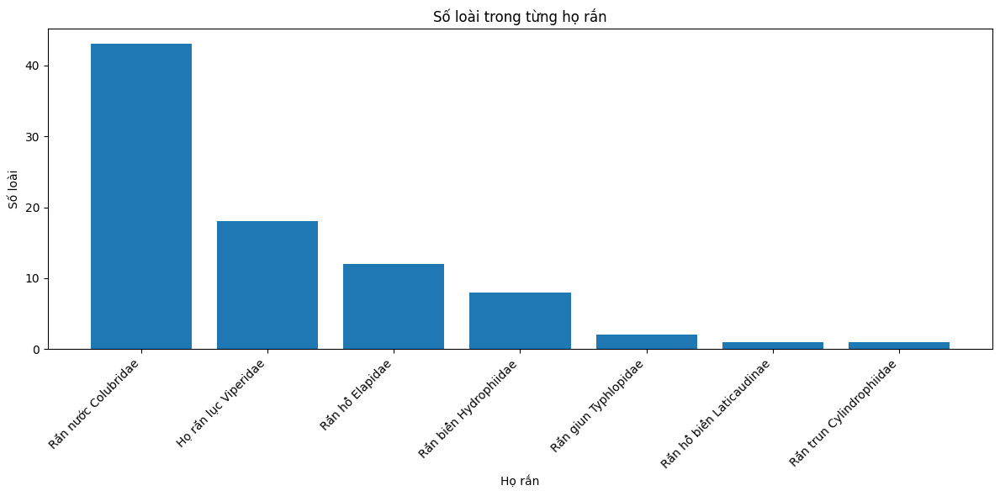

In [6]:
plt.figure(figsize=(12, 6))
plt.bar(summary["HoRan"], summary["SoLoai"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Họ rắn")
plt.ylabel("Số loài")
plt.title("Số loài trong từng họ rắn")
plt.tight_layout()
plt.show()

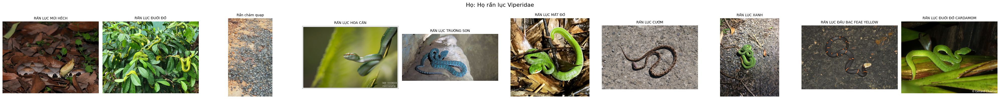

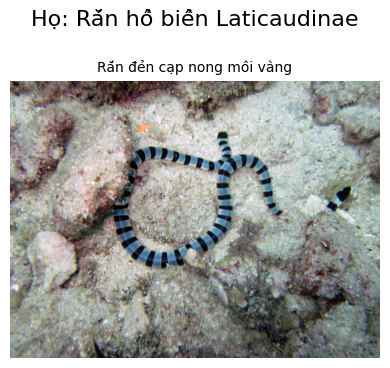

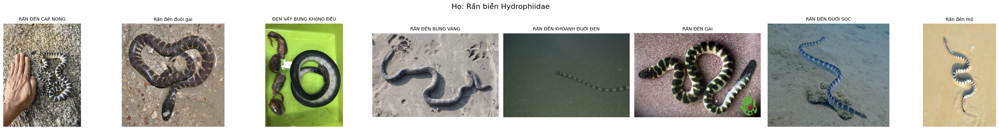

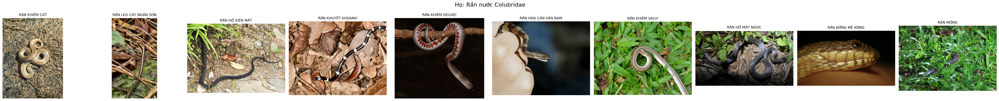

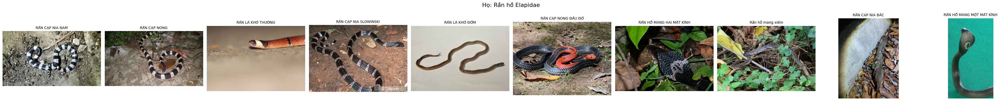

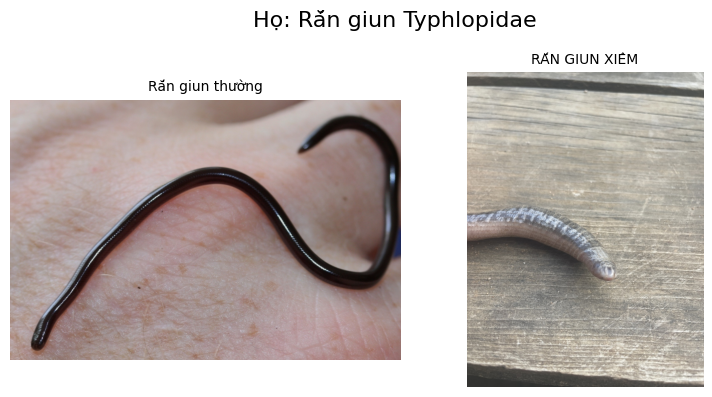

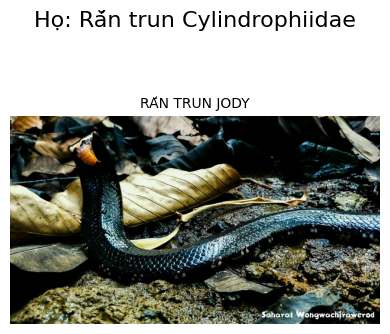

In [4]:
#Hiển thị hình ảnh ngẫu nhiên theo họ
import cv2
import pandas as pd
import matplotlib.pyplot as plt

so_loai_moi_ho = 10

for ho in df["HoRan"].unique():
    df_ho = df[df["HoRan"] == ho]
    cac_loai = df_ho["TenRan"].drop_duplicates()
    cac_loai = cac_loai.sample(n=min(so_loai_moi_ho, len(cac_loai)))

    samples = []
    for ten in cac_loai:
        img_sample = df_ho[df_ho["TenRan"] == ten].sample(1)
        samples.append(img_sample.iloc[0])

    species_samples = pd.DataFrame(samples)
    n = len(species_samples)
    if n == 0:
        continue

    plt.figure(figsize=(4 * n, 4))
    plt.suptitle(f"Họ: {ho}", fontsize=16)

    for plot_idx in range(n):
        row = species_samples.iloc[plot_idx]
        img = cv2.imread(row["Path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, plot_idx + 1)
        plt.imshow(img)
        plt.title(row["TenRan"], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

MÔ HÌNH XGBOOST CHIA CHIA THEO 75-15-15

In [5]:
!pip install opencv-python

In [7]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

SOURCE_DIR = '/content/drive/MyDrive/Trại rắn ĐT /Rắn/Cleaned_Images_All'

# Khởi tạo đặc trưng (X) và nhãn (y)
X_features = []
y_labels = []

# Kích thước chuẩn hóa cho ảnh trước khi chạy HOG
IMG_SIZE = (224,224)

# ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
for file in os.listdir(SOURCE_DIR):
    # Chỉ lấy ảnh Rắn Có Độc (1) và Không Độc (0)
    if file.startswith('CoDoc'):
        label = 1
    elif file.startswith('KhongDoc'):
        label = 0
    else:
        continue

    img_path = os.path.join(SOURCE_DIR, file)
    img = cv2.imread(img_path)

    if img is None:
        continue
  # TIỀN XỬ LÝ
    # Thay đổi kích thước
    img_resized = cv2.resize(img, IMG_SIZE)
    # Chuyển sang ảnh xám (HOG làm việc tốt nhất trên ảnh xám)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray)
    hog_features = hog(gray_clahe, orientations=9, pixels_per_cell=(16, 16),
                       cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    color_features = hist.flatten()

    # TRÍCH XUẤT ĐẶC TRƯNG (HOG) ---
    combined_features = np.hstack((hog_features, color_features))
    X_features.append(combined_features)
    y_labels.append(label)
print(f"Đã trích xuất thành công {len(X_features)} mẫu ảnh.")

# Chuyển list thành mảng Numpy để XGBoost
X = np.array(X_features)
y = np.array(y_labels)

# CHIA TẬP DỮ LIỆU (70% Train - 15% Validation - 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f"\n--- THỐNG KÊ TẬP DỮ LIỆU ---")
print(f"Dữ liệu Huấn luyện (Train) : {X_train.shape[0]} mẫu")
print(f"Dữ liệu Xác thực (Val)     : {X_val.shape[0]} mẫu")
print(f"Dữ liệu Kiểm thử (Test)    : {X_test.shape[0]} mẫu")



Đã trích xuất thành công 4179 mẫu ảnh.

--- THỐNG KÊ TẬP DỮ LIỆU ---
Dữ liệu Huấn luyện (Train) : 2925 mẫu
Dữ liệu Xác thực (Val)     : 627 mẫu
Dữ liệu Kiểm thử (Test)    : 627 mẫu


### Kiểm tra sự cân bằng của các lớp (Có độc/Không độc) trong tập huấn luyện và kiểm tra

In [8]:
import numpy as np

# Kiểm tra phân bố lớp trong tập huấn luyện
print("Phân bố lớp trong tập huấn luyện (y_train):")
train_counts = np.bincount(y_train)
print(f"Không độc (0): {train_counts[0]} mẫu")
print(f"Có độc (1): {train_counts[1]} mẫu")

# Kiểm tra phân bố lớp trong tập kiểm tra
print("\nPhân bố lớp trong tập kiểm tra (y_test):")
test_counts = np.bincount(y_test)
print(f"Không độc (0): {test_counts[0]} mẫu")
print(f"Có độc (1): {test_counts[1]} mẫu")

Phân bố lớp trong tập huấn luyện (y_train):
Không độc (0): 1468 mẫu
Có độc (1): 1457 mẫu

Phân bố lớp trong tập kiểm tra (y_test):
Không độc (0): 315 mẫu
Có độc (1): 312 mẫu


[0]	validation_0-logloss:0.68026	validation_1-logloss:0.69221
[50]	validation_0-logloss:0.36507	validation_1-logloss:0.66768
[100]	validation_0-logloss:0.20866	validation_1-logloss:0.65723
[150]	validation_0-logloss:0.12149	validation_1-logloss:0.65569
[200]	validation_0-logloss:0.07248	validation_1-logloss:0.65774
[250]	validation_0-logloss:0.04574	validation_1-logloss:0.66044
[299]	validation_0-logloss:0.03091	validation_1-logloss:0.66569
--- BÁO CÁO KẾT QUẢ PHÂN LOẠI TRÊN TẬP TEST ---
               precision    recall  f1-score   support

Không độc (0)       0.60      0.58      0.59       315
   Có độc (1)       0.59      0.61      0.60       312

     accuracy                           0.59       627
    macro avg       0.59      0.59      0.59       627
 weighted avg       0.59      0.59      0.59       627



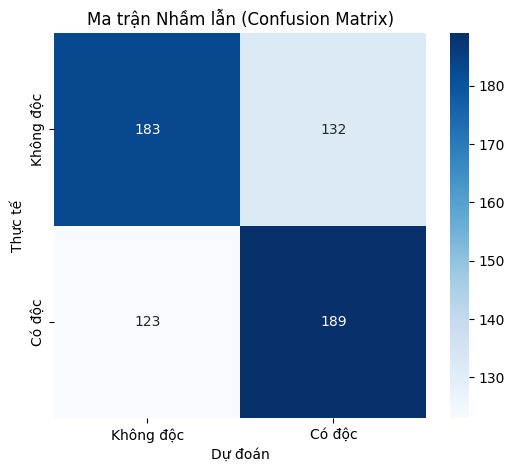

In [9]:
# HUẤN LUYỆN MÔ HÌNH XGBOOST
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,      # Số lượng cây quyết định
    learning_rate=0.05,    # Tốc độ học
    max_depth=6,           # Độ sâu của cây
    random_state=42,
    eval_metric='logloss'
)
# Đưa tập Validation vào mô hình
eval_set = [(X_train, y_train), (X_val, y_val)]
xgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=50
)

# ĐÁNH GIÁ MÔ HÌNH
y_pred = xgb_model.predict(X_test)

print("--- BÁO CÁO KẾT QUẢ PHÂN LOẠI TRÊN TẬP TEST ---")
print(classification_report(y_test, y_pred, target_names=['Không độc (0)', 'Có độc (1)']))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không độc', 'Có độc'],
            yticklabels=['Không độc', 'Có độc'])
plt.title('Ma trận Nhầm lẫn (Confusion Matrix)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()